# Reconstruction example

We use GP to reconstruct two functions $f(x)$ and $g(x)$ and use these reconstruction to build the derived function

$$D(x) = g'(x)/f(x)$$

In [1]:
import sys,os
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from reconstruction_tools.GaussianProcess import GPCalculator

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

# 1) Create data

## Generating function one

In [2]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

In [3]:
order = 3

fiducial_func1 = {'a0': 3,
                  'a1': -1,
                  'a2': 5,
                  'a3': -0.1}

x_label = r'$x$'
y_label_func1 = r'$f(x)$'

In [4]:
from reconstruction_tools.PolynomialFit import PolynomialFit
theory1 = PolynomialFit(None,None,order=order)
theory_model_func1 = lambda x: theory1.generate(x,[float(par) for par in fiducial_func1.values()])

In [5]:
dataset_func1 = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model_func1(dataset_func1['x'])['f']
errors = abs(thvals)*err_fac/100
dataset_func1['f'] = np.random.normal(thvals,errors)
dataset_func1['f_err'] = errors

covmat_func1 = pd.DataFrame(np.diag(errors*2),columns=['f_{}'.format(ind) for ind in range(len(dataset_func1['x']))])
covmat_func1.index = covmat_func1.columns

## Generating function two

In [6]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

In [7]:
order = 3

fiducial_func2 = {'a0': 0,
                  'a1': 1,
                  'a2': -2,
                  'a3':0.5}

x_label = r'$x$'
y_label_func2 = r'$g(x)$'

In [8]:
from reconstruction_tools.PolynomialFit import PolynomialFit
theory2 = PolynomialFit(None,None,order=order)
theory_model_func2 = lambda x: theory2.generate(x,[float(par) for par in fiducial_func2.values()])

In [9]:
dataset_func2 = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model_func2(dataset_func2['x'])['f']
errors = abs(thvals)*err_fac/100
dataset_func2['f'] = np.random.normal(thvals,errors)
dataset_func2['f_err'] = errors

covmat_func2 = pd.DataFrame(np.diag(errors*2),columns=['f_{}'.format(ind) for ind in range(len(dataset_func2['x']))])
covmat_func2.index = covmat_func2.columns

## Plot data

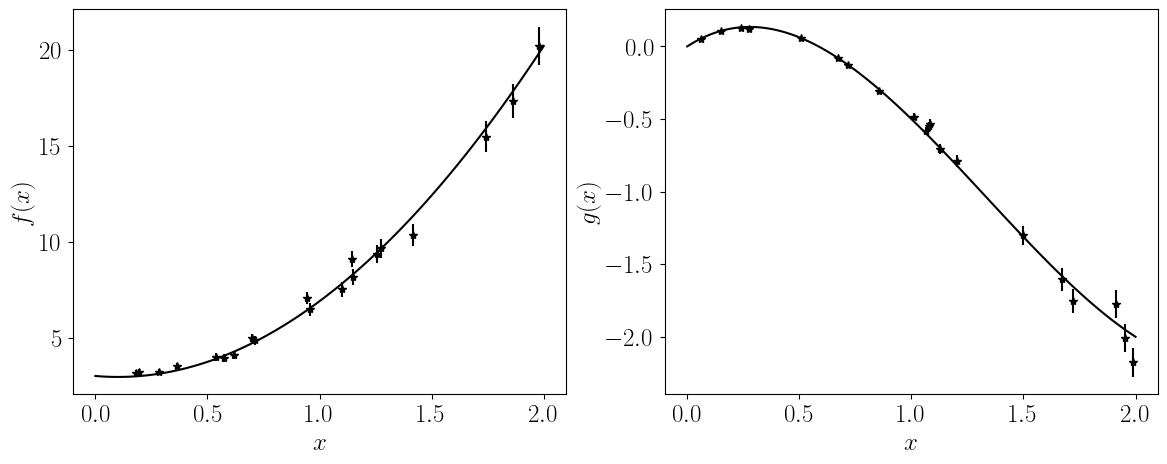

In [10]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(14,5))
axes[0].plot(xplot,theory_model_func1(xplot)['f'],color='black')
axes[0].errorbar(dataset_func1['x'],dataset_func1['f'],yerr=dataset_func1['f_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(x_label)
axes[0].set_ylabel(y_label_func1)

axes[1].plot(xplot,theory_model_func2(xplot)['f'],color='black')
axes[1].errorbar(dataset_func2['x'],dataset_func2['f'],yerr=dataset_func2['f_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(x_label)
axes[1].set_ylabel(y_label_func2);

# 2) Observable reconstruction

## Settings

In [11]:
N_recon = 5
xmin_recon = 0.1
xmax_recon = 1.8
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

possible_derivatives = ['f','int','d1','d2']

kernel = 'RBF'

#methods = ['MAP']
methods = ['BAYESIAN','MAP']
colors  = [red,yellow]

In [12]:
all_reconstructions = {method: {} for method in methods}

## Function one

### Perform reconstruction

In [13]:
gp = GPCalculator(dataset_func1,covmat_func1,kernel_type=kernel)

In [14]:
covmats = []
meandf = []
for method in methods:
    tini = time()
    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)
    means['Method'] = method
    covmats.append(joint_cov)
    meandf.append(means)

    all_reconstructions[method]['fx'] = {'means': means,
                                         'covmat': joint_cov}

    print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

allmeans = pd.concat(meandf,ignore_index=True)

Removed no burn in
GP (BAYESIAN) done in 152.75 s
GP (MAP) done in 1.22 s


### Plot reconstruction

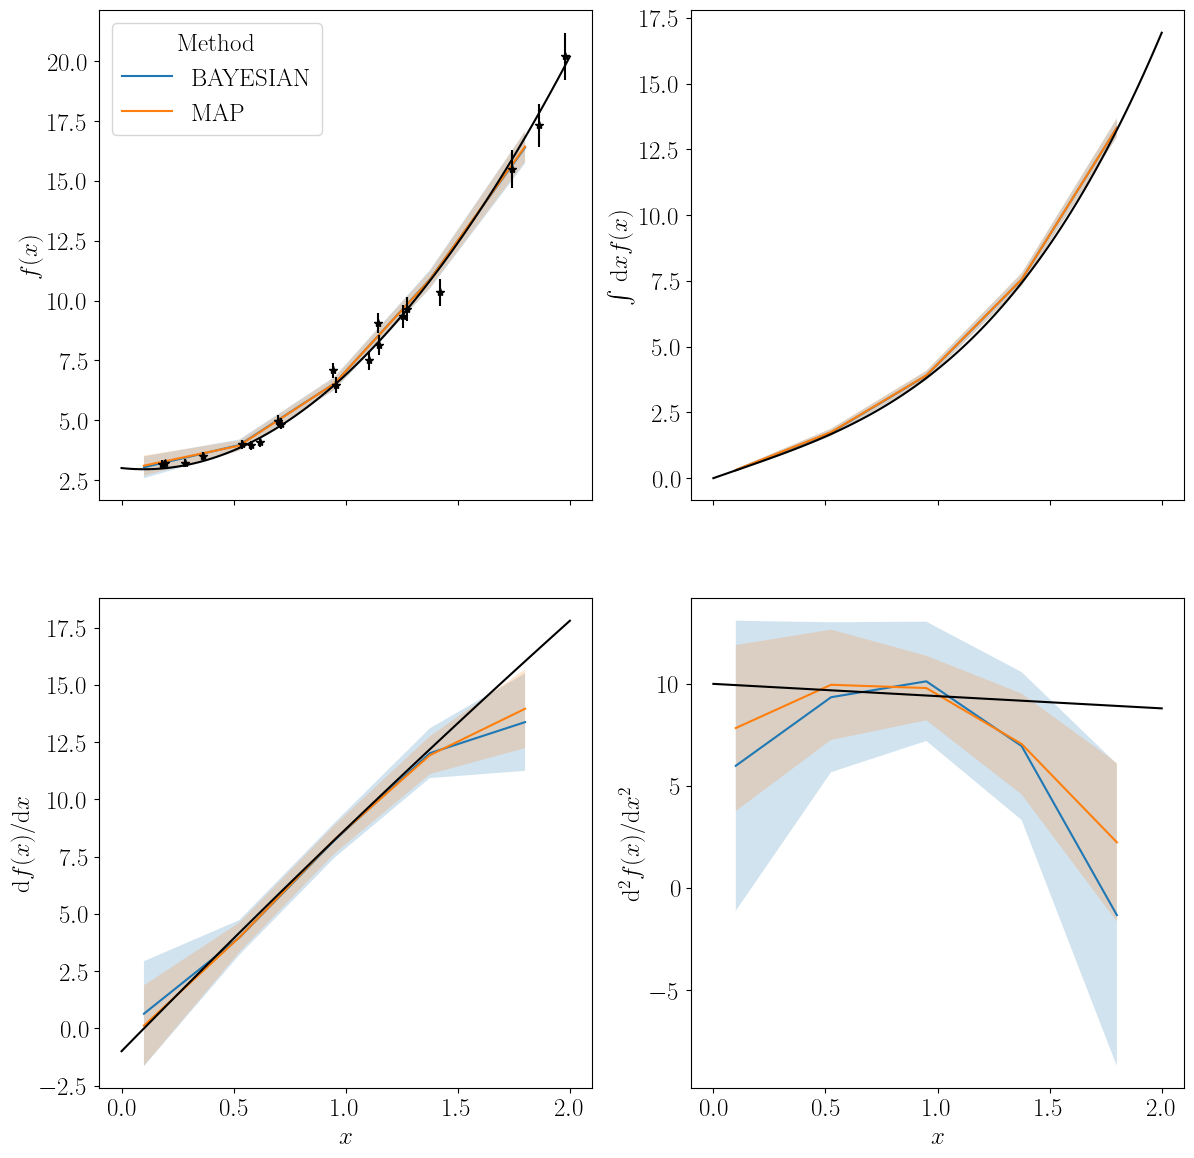

In [15]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label_func1
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label_func1
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label_func1+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label_func1+'/d'+x_label+r'$^2$'

    for method in methods:
        df = allmeans[allmeans['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method')
    else:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method',legend=0)
    axes[i,j].plot(xplot,theory_model_func1(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset_func1['x'],dataset_func1[deriv],yerr=dataset_func1[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Function two

### Perform reconstruction

In [16]:
gp = GPCalculator(dataset_func2,covmat_func2,kernel_type=kernel)

In [17]:
covmats = []
meandf = []
for method in methods:
    tini = time()
    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)
    means['Method'] = method
    covmats.append(joint_cov)
    meandf.append(means)

    all_reconstructions[method]['gx'] = {'means': means,
                                         'covmat': joint_cov}

    print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

allmeans = pd.concat(meandf,ignore_index=True)

Removed no burn in
GP (BAYESIAN) done in 144.81 s
GP (MAP) done in 1.24 s


### Plot reconstruction

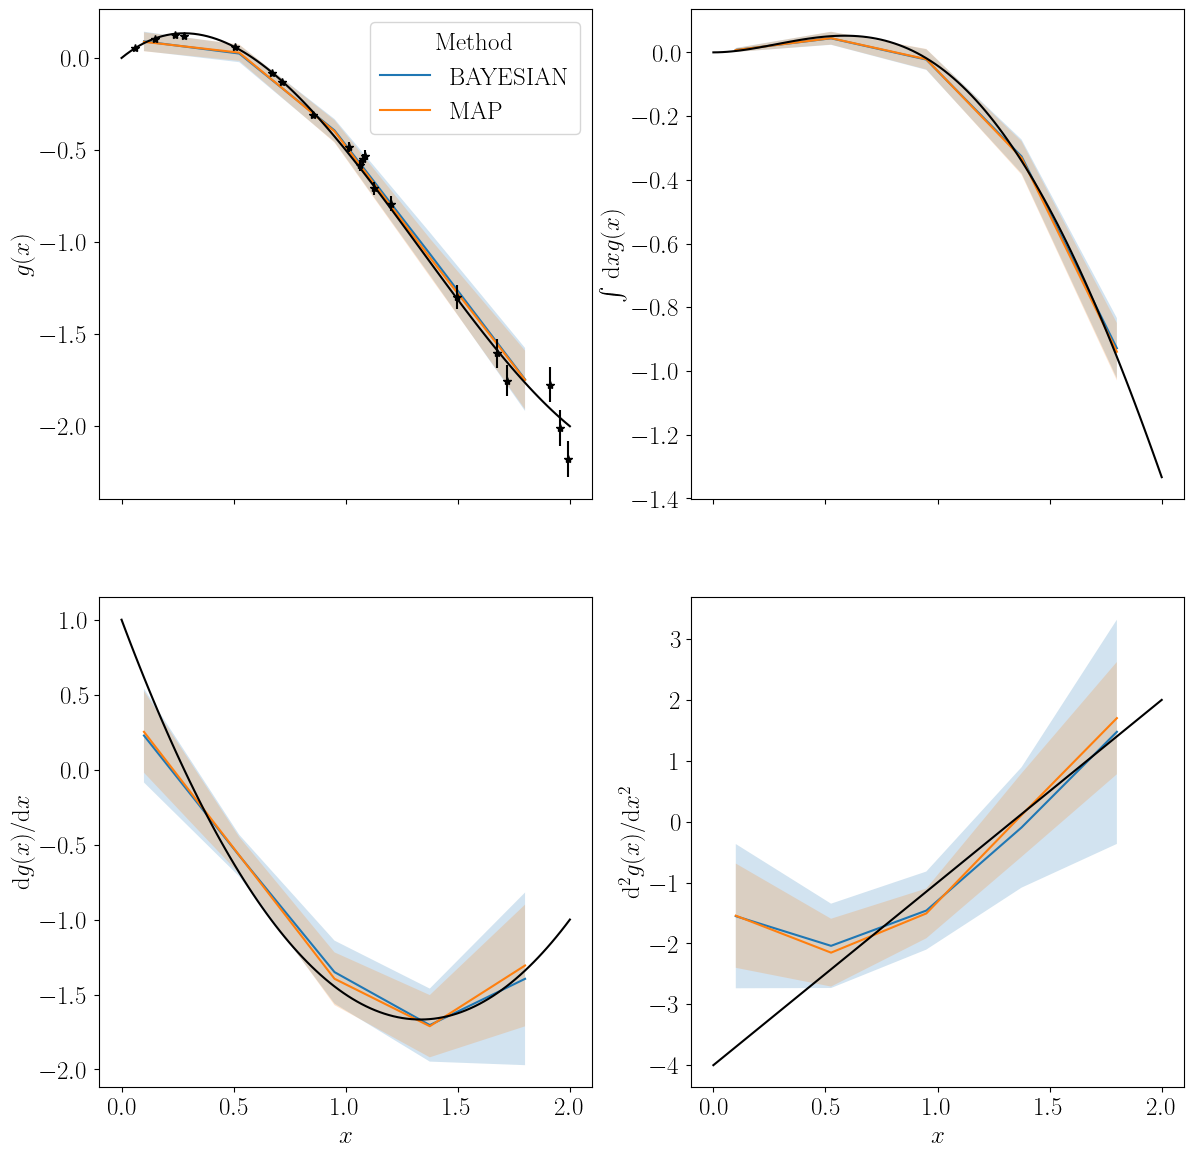

In [18]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label_func2
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label_func2
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label_func2+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label_func2+'/d'+x_label+r'$^2$'

    for method in methods:
        df = allmeans[allmeans['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method')
    else:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method',legend=0)
    axes[i,j].plot(xplot,theory_model_func2(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset_func2['x'],dataset_func2[deriv],yerr=dataset_func2[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

# 3) Obtain derived function

$$D(x)=g'(x)/f(x)$$

In [19]:
from derived_function.reconstructor import DerivedFunction

## Run reconstruction

In [20]:
results = {}
for ind,method in enumerate(methods):

    recon_dict = {k: v['means'] for k,v in all_reconstructions[method].items()}
    cov_dict   = {k: v['covmat'] for k,v in all_reconstructions[method].items()}

    reconstructor = DerivedFunction(recon_dict,cov_dict,sampler='Nautilus',run_options='poor',chatty=True)

    derived_logic = lambda fx_f,gx_d1: gx_d1/fx_f
    derived_name  = 'D'
    
    results[method] = {'sample': reconstructor.run(derived_logic,derived_name,sigma_width=5),
                       'color': colors[ind]}

Detected required variables for derived function: [('fx', 'f', 'fx_f'), ('gx', 'd1', 'gx_d1')]
Starting sampler for 10 parameters...
Loaded prior into Nautilus with dimension 10
Prior keys:  ['fx_f_0', 'fx_f_1', 'fx_f_2', 'fx_f_3', 'fx_f_4', 'gx_d1_0', 'gx_d1_1', 'gx_d1_2', 'gx_d1_3', 'gx_d1_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 24     | 1        | 2        | 18880    | N/A    | 10048 | -15.15   
NAUTILUS SAMPLING FINISHED
Removed no burn in
Detected required variables for derived function: [('fx', 'f', 'fx_f'), ('gx', 'd1', 'gx_d1')]
Starting sampler for 10 parameters...
Loaded prior into Nautilus with dimension 10
Prior keys:  ['fx_f_0', 'fx_f_1', 'fx_f_2', 'fx_f_3', 'fx_f_4', 'gx_d1_0', 'gx_d1_1', 'gx_d1_2', 'gx_d1_3', 'gx_d1_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Ple

## Plotting parameters

### Primary

In [21]:
fiducial_primary = {'fx_f_{}'.format(ind): theory_model_func1(x)['f'] for ind,x in enumerate(x_recon)}
fiducial_primary = fiducial_primary | {'gx_d1_{}'.format(ind): theory_model_func2(x)['d1'] for ind,x in enumerate(x_recon)}

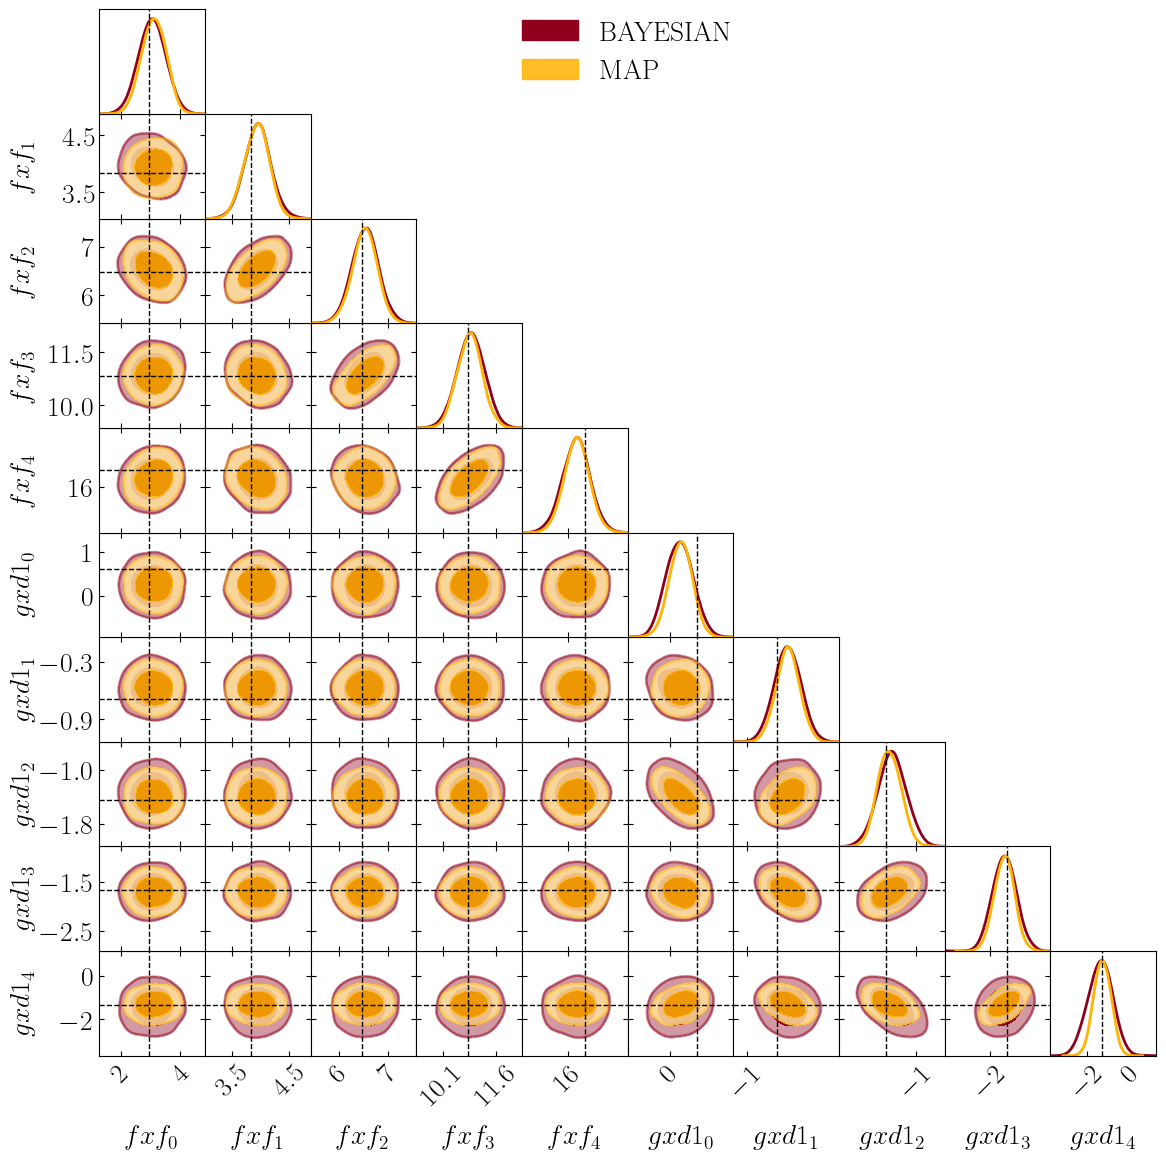

In [22]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_primary.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
                legend_labels=list(results.keys()),
                markers=fiducial_primary
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Derived

In [23]:
fiducial_recon = {'D_{}'.format(ind): theory_model_func2(x_recon[ind])['d1']/theory_model_func1(x_recon[ind])['f'] 
                  for ind in range(N_recon)}

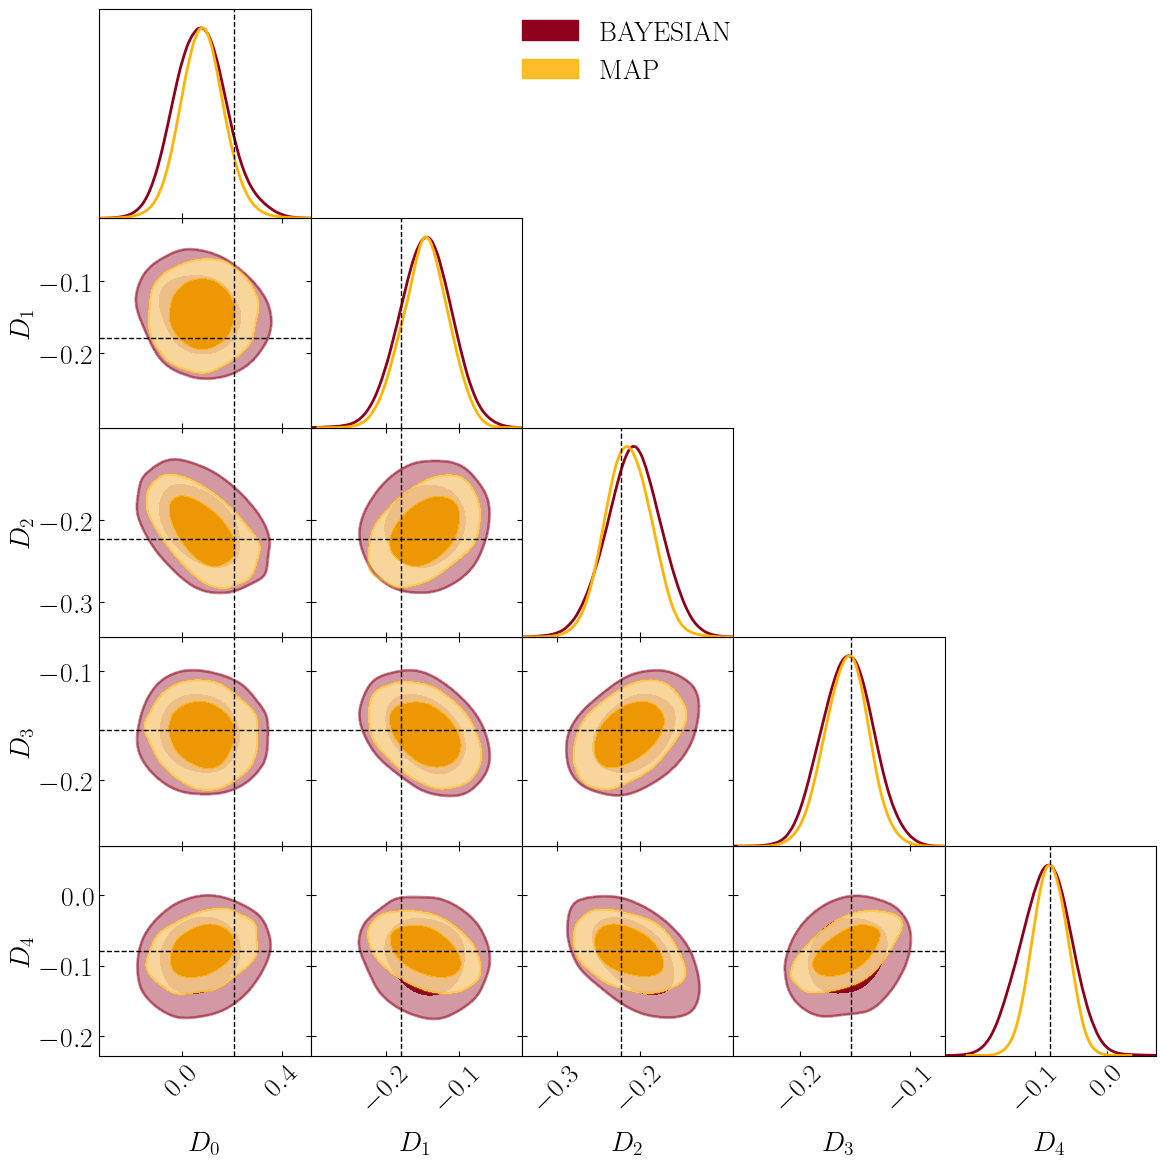

In [24]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_recon.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
                legend_labels=list(results.keys()),
                markers=fiducial_recon
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

## Plotting reconstructed function

In [25]:
for method in methods:
    sample = results[method]['sample']
    results[method]['reconstruction'] = pd.DataFrame({'x': x_recon})
    results[method]['reconstruction']['value'] = sample.getMeans()[2*N_recon:]
    results[method]['reconstruction']['error'] = np.sqrt(sample.getVars()[2*N_recon:])

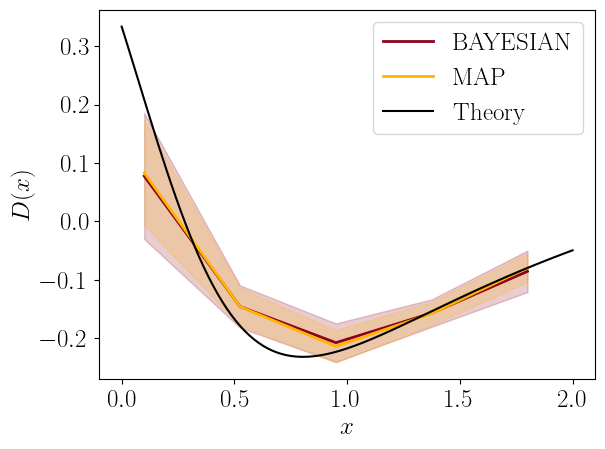

In [26]:
xplot = np.linspace(xmin,xmax,100)

plt.figure()
for method in methods:
    reconstruction = results[method]['reconstruction']
    plt.fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                     reconstruction['value']-reconstruction['error'],alpha=0.2,color=results[method]['color'])
    plt.plot(reconstruction['x'],reconstruction['value'],lw=2,color=results[method]['color'],label=method)
plt.plot(xplot,theory_model_func2(xplot)['d1']/theory_model_func1(xplot)['f'],color='black',label='Theory')
plt.xlabel(x_label)
plt.ylabel(r'$D(x)$')
plt.legend(loc='best');